In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import pickle

df = pd.read_csv('../data/processed/cleaned_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Rows:", df.shape[0])
print("Ready for forecasting!")

Rows: 805549
Ready for forecasting!


In [2]:
# Aggregate total revenue per day
daily_revenue = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_revenue.columns = ['Date', 'Revenue']
daily_revenue['Date'] = pd.to_datetime(daily_revenue['Date'])
daily_revenue = daily_revenue.sort_values('Date').reset_index(drop=True)

print("Total days:", len(daily_revenue))
print(daily_revenue.head())

Total days: 604
        Date   Revenue
0 2009-12-01  44048.69
1 2009-12-02  52941.99
2 2009-12-03  67479.08
3 2009-12-04  34064.41
4 2009-12-05   9803.05


In [3]:
daily_revenue['DayOfWeek']  = daily_revenue['Date'].dt.dayofweek
daily_revenue['Month']      = daily_revenue['Date'].dt.month
daily_revenue['WeekOfYear'] = daily_revenue['Date'].dt.isocalendar().week.astype(int)
daily_revenue['IsWeekend']  = daily_revenue['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
daily_revenue['Lag7']       = daily_revenue['Revenue'].shift(7)   # revenue 7 days ago
daily_revenue['Lag30']      = daily_revenue['Revenue'].shift(30)  # revenue 30 days ago
daily_revenue['Rolling7']   = daily_revenue['Revenue'].rolling(7).mean()  # 7 day average

# Drop rows with NaN caused by lag/rolling
daily_revenue = daily_revenue.dropna().reset_index(drop=True)

print("Shape after adding features:", daily_revenue.shape)
print(daily_revenue.head())

Shape after adding features: (574, 9)
        Date    Revenue  DayOfWeek  Month  WeekOfYear  IsWeekend      Lag7  \
0 2010-01-14  23843.470          3      1           2          0   8740.69   
1 2010-01-15  13507.540          4      1           2          0  73035.23   
2 2010-01-17  17548.290          6      1           2          1  30317.80   
3 2010-01-18  12132.690          0      1           3          0  23248.08   
4 2010-01-19  22011.471          1      1           3          0  19685.34   

      Lag30      Rolling7  
0  44048.69  31634.720000  
1  52941.99  23130.764286  
2  67479.08  21306.548571  
3  34064.41  19718.635714  
4   9803.05  20050.940143  


In [4]:
feature_cols = ['DayOfWeek', 'Month', 'WeekOfYear', 'IsWeekend', 'Lag7', 'Lag30', 'Rolling7']

X = daily_revenue[feature_cols]
y = daily_revenue['Revenue']

# Time based split — 80% train, 20% test
split_index = int(len(daily_revenue) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 459
Testing rows: 115


In [5]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [6]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print("======= MODEL PERFORMANCE =======")
print(f"MAE  (Mean Absolute Error):  £{mae:,.2f}")
print(f"RMSE (Root Mean Sq Error):   £{rmse:,.2f}")
print(f"MAPE (Mean Abs % Error):     {mape:.2f}%")
print(f"\nAccuracy: {100 - mape:.2f}%")

======= MODEL PERFORMANCE =======
MAE  (Mean Absolute Error):  £11,241.36
RMSE (Root Mean Sq Error):   £18,158.62
MAPE (Mean Abs % Error):     34.88%

Accuracy: 65.12%


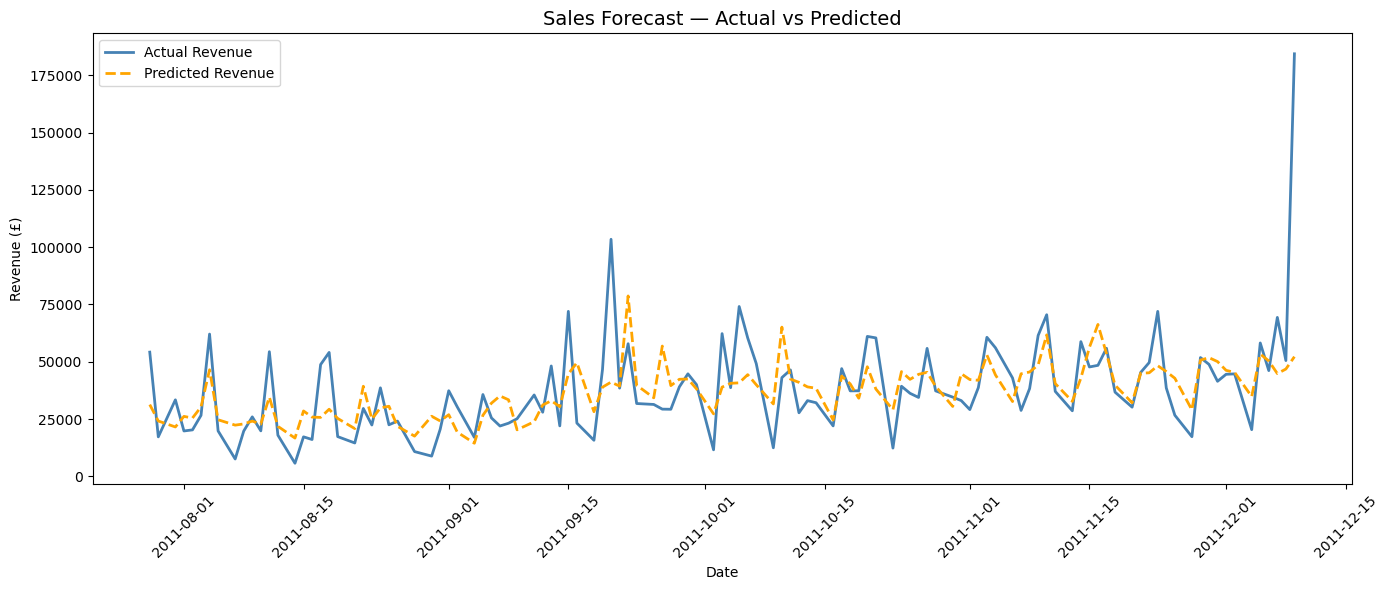

✅ Saved to outputs/chart_forecast.png


In [7]:
test_dates = daily_revenue['Date'][split_index:].reset_index(drop=True)

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test.values, label='Actual Revenue',    color='steelblue', linewidth=2)
plt.plot(test_dates, y_pred,        label='Predicted Revenue', color='orange',    linewidth=2, linestyle='--')
plt.title('Sales Forecast — Actual vs Predicted', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/chart_forecast.png')
plt.show()
print("✅ Saved to outputs/chart_forecast.png")

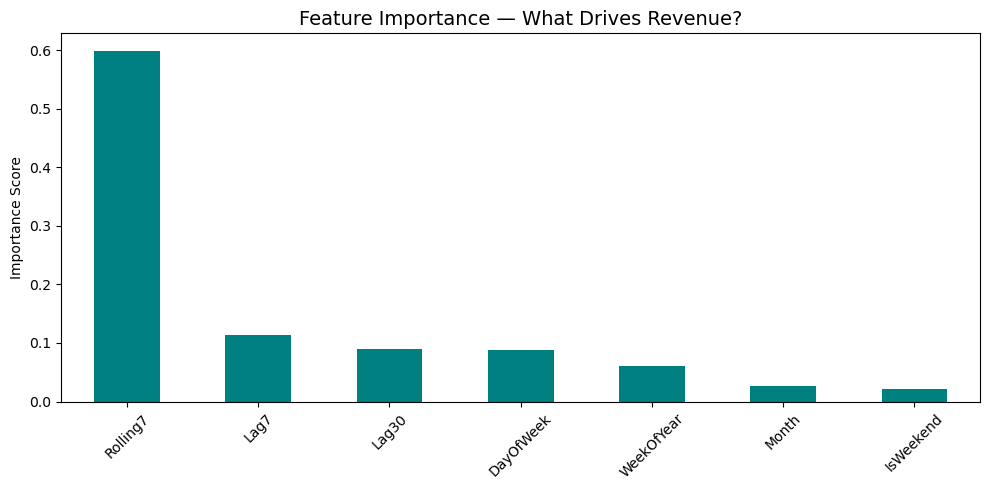

✅ Saved to outputs/chart_feature_importance.png


In [8]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.plot(kind='bar', color='teal')
plt.title('Feature Importance — What Drives Revenue?', fontsize=14)
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/chart_feature_importance.png')
plt.show()
print("✅ Saved to outputs/chart_feature_importance.png")

In [9]:
with open('../models/forecast_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Also save daily revenue for use in Streamlit app later
daily_revenue.to_csv('../data/processed/daily_revenue.csv', index=False)

print("✅ Model saved to models/forecast_model.pkl")
print("✅ Daily revenue saved to data/processed/daily_revenue.csv")

✅ Model saved to models/forecast_model.pkl
✅ Daily revenue saved to data/processed/daily_revenue.csv
